Fundamentals of Deep Learning Models

# Lab 08-2: Sequence Model of RNN (TensorFlow)
## Exercise: Character-based text generation with embedding

This exercise implements a **character-level language model** using TensorFlow/Keras,
combining an **embedding layer** (Section 8.7) with a **vanilla RNN** (Section 8.1)
and a dense output layer. The model is trained on the Tiny Shakespeare dataset
to predict the next character given a sequence of preceding characters.

Unlike Lab 08-1 which used one-hot encoding, this exercise uses learned embeddings
that map discrete tokens to dense vectors (Section 8.7), reducing input dimensionality
and enabling the model to capture semantic similarities between characters.

Reference: Adapted from the TensorFlow text generation tutorial
(https://www.tensorflow.org/text/tutorials/text_generation), licensed under Apache 2.0.

### Load libraries and dataset

In [18]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import time

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)
print('TensorFlow Datasets version:', tfds.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

# Check available GPU devices
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.13.2
TensorFlow Datasets version: 4.9.9
Matplotlib version: 3.10.0
Num GPUs Available:  1


In [2]:
# Load Tiny Shakespeare dataset (public domain text)
(ds, ), ds_info = tfds.load(name='tiny_shakespeare', split=['train'], with_info=True)

ds = ds.map(lambda x: tf.strings.unicode_split(x['text'], 'UTF-8'))
for sample in ds.take(1):
    text_str = sample

print(ds_info)
print('Total number of characters:', len(text_str))

tfds.core.DatasetInfo(
    name='tiny_shakespeare',
    full_name='tiny_shakespeare/1.0.0',
    description="""
    40,000 lines of Shakespeare from a variety of Shakespeare's plays. Featured in
    Andrej Karpathy's blog post 'The Unreasonable Effectiveness of Recurrent Neural
    Networks': http://karpathy.github.io/2015/05/21/rnn-effectiveness/.
    
    To use for e.g. character modelling:
    
    ```
    d = tfds.load(name='tiny_shakespeare')['train']
    d = d.map(lambda x: tf.strings.unicode_split(x['text'], 'UTF-8'))
    # train split includes vocabulary for other splits
    vocabulary = sorted(set(next(iter(d)).numpy()))
    d = d.map(lambda x: {'cur_char': x[:-1], 'next_char': x[1:]})
    d = d.unbatch()
    seq_len = 100
    batch_size = 2
    d = d.batch(seq_len)
    d = d.batch(batch_size)
    ```
    """,
    homepage='https://github.com/karpathy/char-rnn/blob/master/data/tinyshakespeare/input.txt',
    data_dir='/root/tensorflow_datasets/tiny_shakespeare/1.0.0',
    fil

### Building vocabulary

Construct a character-level vocabulary that maps each unique character to an integer index.
This integer representation is subsequently converted to a dense embedding vector
by the embedding layer (Section 8.7).

In [3]:
vocabulary = sorted(set(text_str.numpy()))

char_to_index = dict((char, index) for index, char in enumerate(vocabulary))

index_to_char = {}
for key, value in char_to_index.items():
    index_to_char[value] = key

print('Vocabulary size:', len(vocabulary))
print('Character to index mapping:\n', char_to_index)

Vocabulary size: 65
Character to index mapping:
 {b'\n': 0, b' ': 1, b'!': 2, b'$': 3, b'&': 4, b"'": 5, b',': 6, b'-': 7, b'.': 8, b'3': 9, b':': 10, b';': 11, b'?': 12, b'A': 13, b'B': 14, b'C': 15, b'D': 16, b'E': 17, b'F': 18, b'G': 19, b'H': 20, b'I': 21, b'J': 22, b'K': 23, b'L': 24, b'M': 25, b'N': 26, b'O': 27, b'P': 28, b'Q': 29, b'R': 30, b'S': 31, b'T': 32, b'U': 33, b'V': 34, b'W': 35, b'X': 36, b'Y': 37, b'Z': 38, b'a': 39, b'b': 40, b'c': 41, b'd': 42, b'e': 43, b'f': 44, b'g': 45, b'h': 46, b'i': 47, b'j': 48, b'k': 49, b'l': 50, b'm': 51, b'n': 52, b'o': 53, b'p': 54, b'q': 55, b'r': 56, b's': 57, b't': 58, b'u': 59, b'v': 60, b'w': 61, b'x': 62, b'y': 63, b'z': 64}


### Building training data pipeline

The text is split into fixed-length windows. For each window, the input is
`chars[0:T]` and the target is `chars[1:T+1]`, forming next-character prediction pairs.
This follows the sliding-window technique described in Section 8.9.

Note: Unlike Lab 08-1, targets here are integer-encoded (not one-hot),
since `SparseCategoricalCrossentropy` is used as the loss function.

In [4]:
ids_from_chars = keras.layers.StringLookup(vocabulary=list(vocabulary), mask_token=None)
chars_from_ids = keras.layers.StringLookup(
    vocabulary=ids_from_chars.get_vocabulary(), invert=True, mask_token=None)

text_ids = ids_from_chars(text_str)

n_voca = len(ids_from_chars.get_vocabulary())

seq_len = 128

# Split text into sequences of length (seq_len + 1)
ds_ids = tf.data.Dataset.from_tensor_slices(text_ids).batch(seq_len+1, drop_remainder=True)

# Create (input, target) pairs: input = chars[0:T], target = chars[1:T+1]
ds_xy = ds_ids.map(lambda x: (x[:-1], x[1:]))

In [5]:
# Display a sample sequence
for seq in ds_ids.take(1):
    print(chars_from_ids(seq))

tf.Tensor(
[b'F' b'i' b'r' b's' b't' b' ' b'C' b'i' b't' b'i' b'z' b'e' b'n' b':'
 b'\n' b'B' b'e' b'f' b'o' b'r' b'e' b' ' b'w' b'e' b' ' b'p' b'r' b'o'
 b'c' b'e' b'e' b'd' b' ' b'a' b'n' b'y' b' ' b'f' b'u' b'r' b't' b'h'
 b'e' b'r' b',' b' ' b'h' b'e' b'a' b'r' b' ' b'm' b'e' b' ' b's' b'p'
 b'e' b'a' b'k' b'.' b'\n' b'\n' b'A' b'l' b'l' b':' b'\n' b'S' b'p' b'e'
 b'a' b'k' b',' b' ' b's' b'p' b'e' b'a' b'k' b'.' b'\n' b'\n' b'F' b'i'
 b'r' b's' b't' b' ' b'C' b'i' b't' b'i' b'z' b'e' b'n' b':' b'\n' b'Y'
 b'o' b'u' b' ' b'a' b'r' b'e' b' ' b'a' b'l' b'l' b' ' b'r' b'e' b's'
 b'o' b'l' b'v' b'e' b'd' b' ' b'r' b'a' b't' b'h' b'e' b'r' b' ' b't'
 b'o' b' ' b'd'], shape=(129,), dtype=string)


In [6]:
def text_from_ids(ids):
    return tf.strings.reduce_join(chars_from_ids(ids), axis=-1)

# Verify the data pipeline
for sample in ds_xy.take(1):
    input_example, target_example = sample
    print("Input :", text_from_ids(input_example).numpy())
    print("Target:", text_from_ids(target_example).numpy())

Input : b'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to '
Target: b'irst Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to d'


In [7]:
buff_size = 10000
batch_size = 64
ds_train = ds_xy.shuffle(buff_size).batch(batch_size, drop_remainder=True)

ds_train

<_BatchDataset element_spec=(TensorSpec(shape=(64, 128), dtype=tf.int64, name=None), TensorSpec(shape=(64, 128), dtype=tf.int64, name=None))>

### RNN model definition

The model consists of three layers:

1. **Embedding layer** (Section 8.7): Maps integer token IDs to dense vectors of dimension `n_embedding`.
   This replaces one-hot encoding with learned distributed representations.
2. **SimpleRNN layer** (Section 8.1): Implements the vanilla RNN recurrence
   $\mathbf{h}_t = \tanh(\mathbf{W}_{hx}\mathbf{x}_t + \mathbf{W}_{hh}\mathbf{h}_{t-1} + \mathbf{b}_h)$ (Eq. 8.3),
   with `glorot_uniform` (Xavier) initialization for $\mathbf{W}_{hx}$ and `orthogonal`
   initialization for $\mathbf{W}_{hh}$ (Section 8.4, Eqs. 8.22–8.23).
3. **Dense layer**: Maps hidden states to logits over the vocabulary,
   corresponding to $\mathbf{o}_t = \mathbf{W}_{yh}\mathbf{h}_t + \mathbf{b}_y$ (Eq. 8.5).
   Softmax is applied inside the loss function rather than in the model output.

The model uses the Keras subclassing API to manage RNN states explicitly,
which is needed for autoregressive text generation at inference time.

In [ ]:
n_voca = len(ids_from_chars.get_vocabulary())

n_embedding = 256  # Embedding dimension (Section 8.7)
n_hidden = 512     # Hidden state dimension n_h

class myRNN(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, rnn_units):
        super().__init__()

        ### START CODE HERE ###

        # Embedding layer: maps token IDs to dense vectors (Section 8.7)
        self.embedding = None

        # SimpleRNN layer: vanilla RNN with tanh activation (Eq. 8.3)
        self.rnn = tf.keras.layers.SimpleRNN(...
                        # W_hx: Xavier init (Section 4.4)
                        # W_hh: orthogonal init (Section 8.4)
                        # return all h_t for dense layer
                )       # also return h_T for stateful generation

        # Dense output layer: maps h_t to logits o_t = W_yh * h_t + b_y (Eq. 8.5)
        self.dense = tf.keras.layers.Dense(...
                ...     # logits; softmax applied in loss function
                )

        ### END CODE HERE ###

    def call(self, inputs, states=None, return_state=False, training=False):

        ### START CODE HERE ###

        # Convert token IDs to embedding vectors (Section 8.7)
        x = self.embedding(...)

        # Initialize hidden state to zeros if not provided
        if states is None:
            states = self.rnn....

        # RNN forward pass: returns (h_all, h_last) (Eq. 8.3)
        x, states = None

        # Output logits: o_t = W_yh * h_t + b_y (Eq. 8.5)
        x = None

        ### END CODE HERE ###

        if return_state:
            return x, states
        else:
            return x

RNN = myRNN(vocab_size=n_voca, embedding_dim=n_embedding, rnn_units=n_hidden)

### Test model before training

In [9]:
# Build model by running a forward pass
input_layer = keras.layers.Input(shape=(seq_len,), sparse=True)
RNN(input_layer)

# Test with a sample batch
for input_example_batch, target_example_batch in ds_train.take(1):
    example_batch_predictions = RNN(input_example_batch)
    print(example_batch_predictions.shape, '# (batch_size, sequence_length, vocab_size)')

(64, 128, 66) # (batch_size, sequence_length, vocab_size)


In [10]:
# Before training, predictions are nearly uniform random
sampled_indices = tf.random.categorical(example_batch_predictions[0], num_samples=1)
sampled_indices = tf.squeeze(sampled_indices, axis=-1).numpy()
print('Input:\n', text_from_ids(input_example_batch[0]).numpy())
print()
print('Next char predictions:\n', text_from_ids(sampled_indices).numpy())

Input:
 b"hat, dress'd! and in your clothes! and down again!\nI must needs wake you; Lady! lady! lady!\nAlas, alas! Help, help! my lady's de"

Next char predictions:
 b"YLlCydLzzRMlgm?sS:\n3FvC;zClHLKIBBKhk [UNK]ND.FUZLLZ[UNK]a.VlvSq G't G[UNK]FYsvagSsVEivMqdpwrrIK:cFMpFFPqENEEYLVudpW-FhBgnOKr$ESIFeRWk3F$oHSF"


In [11]:
RNN.summary()

Model: "my_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 256)       │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ((None, 128, 512),     │       393,728 │
│                                 │ (None, 512))           │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128, 66)        │        33,858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,482 (1.70 MB)

 Trainable params: 444,482 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

### Training

The model is trained with `SparseCategoricalCrossentropy(from_logits=True)`,
which internally applies softmax to the logits $\mathbf{o}_t$ and computes the
cross-entropy loss (Eq. 8.6). The Adam optimizer is used for parameter updates.

Note: Using `from_logits=True` is numerically more stable than applying softmax
separately and computing log-probabilities, as it avoids potential log(0) issues.

In [12]:
# Loss: sparse cross-entropy on logits (Eq. 8.6)
loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Optimizer: Adam (Section 4.3)
opti = keras.optimizers.Adam(learning_rate=1e-3)

# Metric: cross-entropy (monitors training convergence)
metr = keras.metrics.SparseCategoricalCrossentropy(
    name='cross_entropy', from_logits=True)

RNN.compile(loss=loss, optimizer=opti, metrics=[metr])

In [13]:
n_epochs = 30

results = RNN.fit(ds_train, epochs=n_epochs, verbose=1)

Epoch 1/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - cross_entropy: 2.5544 - loss: 2.5544
Epoch 2/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - cross_entropy: 2.0297 - loss: 2.0297
Epoch 3/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - cross_entropy: 1.8573 - loss: 1.8573
Epoch 4/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - cross_entropy: 1.7441 - loss: 1.7441
Epoch 5/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - cross_entropy: 1.6633 - loss: 1.6633
Epoch 6/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - cross_entropy: 1.6047 - loss: 1.6047
Epoch 7/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - cross_entropy: 1.5589 - loss: 1.5589
Epoch 8/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - cross_entropy: 1.5256 - loss: 1.5256
Epoch 9/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - cross_entropy: 1.4944 - loss: 1.4944
Epoch 10/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - cross_entropy: 1.4701 - loss: 1.4701
Epoch 11/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - cross_entropy: 1.4502 -

### Plot convergence

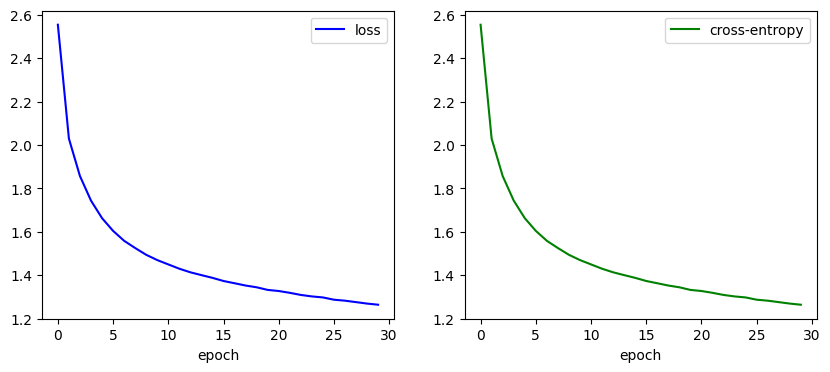

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(results.history['loss'], 'b-', label='loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results.history['cross_entropy'], 'g-', label='cross-entropy')
plt.xlabel('epoch')
plt.legend()

plt.show()

### Text generation

At inference time, the model generates text autoregressively: at each step,
the predicted character is fed back as input for the next step, and the hidden
state is carried forward to maintain context. This is analogous to the
autoregressive decoding process described in Section 9.1.

A `temperature` parameter controls the randomness of sampling:
lower values produce more deterministic (but repetitive) output,
while higher values produce more diverse (but noisier) output.

In [15]:
class OneStep(keras.Model):
    """Wrapper for single-step autoregressive generation."""
    def __init__(self, model, chars_from_ids, ids_from_chars, temperature=1.0):
        super().__init__()
        self.temperature = temperature
        self.model = model
        self.chars_from_ids = chars_from_ids
        self.ids_from_chars = ids_from_chars

        # Create a mask to prevent '[UNK]' from being generated
        skip_ids = self.ids_from_chars(['[UNK]'])[:, None]
        sparse_mask = tf.SparseTensor(
            values=[-float('inf')] * len(skip_ids),
            indices=skip_ids,
            dense_shape=[len(ids_from_chars.get_vocabulary())])
        self.prediction_mask = tf.sparse.to_dense(sparse_mask)

    @tf.function
    def generate_one_step(self, inputs, states=None):
        # Convert string input to token IDs
        input_chars = tf.strings.unicode_split(inputs, 'UTF-8')
        input_ids = self.ids_from_chars(input_chars).to_tensor()

        # Forward pass through the model
        predicted_logits, states = self.model(
            inputs=input_ids, states=states, return_state=True)

        # Use only the last time step prediction
        predicted_logits = predicted_logits[:, -1, :]
        predicted_logits = predicted_logits / self.temperature

        # Mask out unknown tokens
        predicted_logits = predicted_logits + self.prediction_mask

        # Sample from the predicted distribution
        predicted_ids = tf.random.categorical(predicted_logits, num_samples=1)
        predicted_ids = tf.squeeze(predicted_ids, axis=-1)

        # Convert token IDs back to characters
        predicted_chars = self.chars_from_ids(predicted_ids)

        return predicted_chars, states

In [16]:
one_step_model = OneStep(RNN, chars_from_ids, ids_from_chars)

In [17]:
# Generate 1000 characters starting from 'ROMEO:'
start = time.time()
states = None
next_char = tf.constant(['ROMEO:'])
result = [next_char]

for n in range(1000):
    next_char, states = one_step_model.generate_one_step(next_char, states=states)
    result.append(next_char)

result = tf.strings.join(result)
print(result[0].numpy().decode('utf-8'), '\n\n' + '_'*80)
print('\nRun time:', time.time() - start)

ROMEO:
Now from my spempler than his still.

First LO:
More other warswers my flesh which I must humour; thereby wind:
Hine, my justing in the commons through the mast
By nature of thee.

Second Servant:
Yet, in dead, thy hand and the towbray?
Moutt I speak not, thou hasted in his eyes. You would give my man's ency.

QUEEN ELIZABETH:
Kind therely so dull and, please,
To saw him my boy, devil be thy great-half?

QUEEN MARGARET:
Pray't a goodly poor footicance,
It weep's this mother: come, cups her hollow inhuedy a maids?

ROMEO:
Nay, I am bud indeed affender,
Or joy, dear revenge in hope goictity here?

LARTIUS:
Daswer, but none all these in holecw go and, by kneel.

BRUTUS:
The spack here;
Inquire the more, the law or better pleasure
Might make it as the Lord Hastings of it?

MAMILLIUS:
No, it saddly comes these head as
you of what they villay together; nor love;
Being plain Aumerle do as yet
Our ragoa, fear? why, these hidvill wear.

ANGELO:
Nursue enemy, and a wicked heart.

HERMIONE

(c) 2026 S. W. Lee